In [1]:
import numpy as np
from qutip import *
from sympy.physics.quantum.cg import CG
from sympy.physics.wigner import wigner_6j, wigner_3j
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.linalg import inv
from numpy import linalg as LA
from scipy.optimize import minimize_scalar
import math
from scipy.optimize import curve_fit
from scipy.sparse.linalg import eigs,spsolve
from scipy.odr import ODR, Model, Data, RealData
import matplotlib.cm as cm
from numpy.linalg import matrix_rank

In [2]:
#toy model's quantum numbers
I = 1
S = 1
Je = 0
Jg = 1
Lg = 2
F = [i for i in range(int(I-Jg),int(I + Jg + 1),1)]
F.insert(0,int(I+Je))
F 

[1, 0, 1, 2]

In [3]:
#number of atomic states
N = [2*F[i] + 1 for i in range(len(F))]
N = sum(N)
N

12

In [4]:
#Zeeman stuff

muB = 9.3e-24 #Bohr magneton J T^-1
hbar = 1.054e-34 # J s

muB = muB/hbar #hbar = 1
muB = muB/(2*np.pi)
muB = muB/1e6  # so it's in 1/2π (MHz T^-1)
#muB=1

# 1Gauss is 0.0001 T
B=5e-04
print(muB*B) 
#gF = [1,0,1,2]
gF = []
FF = [7,6,7,8]
II = 7


#Lande g factor for real Lu with I=7
me = 9.1093837015e-31 
mp = 1.67262192369e-27 

mI = 3.169 #nuclear magnetic moment of 176Lu in units of μN
gI = mI/II
gJg = 1 + (Jg*(Jg +1) + S*(S + 1) - Lg*(Lg + 1))/(2*Jg*(Jg + 1))


gF.append(-gI*me/mp)

for i in range(3):
    gF.append(gJg*(FF[i +1]*(FF[i+1] + 1) + Jg*(Jg+1) - II*(II+1))/(2*FF[i+1]*(FF[i +1] + 1)))

    
print(gF)

7.021541606995384
[-0.0002465559058692723, -0.07142857142857142, 0.008928571428571428, 0.0625]


In [5]:
-gI*me/mp

-0.0002465559058692723

In [6]:
for i in range(len(F)):
    print(gF[i]*muB*B) #(1/2π MHz)

-0.0017312025515115329
-0.5015386862139559
0.06269233577674449
0.4388463504372115


In [7]:
def base(F,i,mF):
    #numbering states from 0 to N-1 starting from -mF to mF
    # 0 is |F',-mF'>
    if i==0:
        b = basis(N,mF+F[i])
    elif i==1:
        b = basis(N,mF + F[i] + 2*F[0] + 1)
    elif i==2:
        b = basis(N,mF + F[i] + 2*F[0] + 1 + 2*F[1] + 1)
    else:
        b = basis(N,mF + F[i] + 2*F[0] + 1 + 2*F[1] + 1 + 2*F[2] +1)
    return b    

## Dissipation

In [8]:
GammaJgJe = 2.44745 #1/2π (MHz) 3D1 to 3P0
#GammaJgJe = 2.5

In [9]:
def GammaFgFe(F,ig,Je,Jg,I,GammaJgJe):
    return float((2*Je + 1)*(2*F[ig] + 1)*wigner_6j(Je,F[0],I,F[ig],Jg,1)**2)*GammaJgJe
    #return GammaJgJe

In [10]:
GammaFgFe(F,1,Je,Jg,I,GammaJgJe) + GammaFgFe(F,2,Je,Jg,I,GammaJgJe) + GammaFgFe(F,3,Je,Jg,I,GammaJgJe)

2.44745

In [11]:
def cg(F,ig,mFg,ie,mFe,q):
    return float(CG(F[ig],mFg,1,q,F[ie],mFe).doit())
    #return 1

In [12]:
cg(F,2,0,0,0,0)

0.0

In [13]:
#checking our normalization convention
for ig in range(1,len(F)):
    we=0
    for mfg in range(-F[ig],F[ig] + 1):
        for mfe in range(-F[0],F[0]+1):
            for q in [-1,0,1]:
                we+=1/(2*F[0] + 1)*cg(F,ig,mfg,0,mfe,q)**2
                
    print(we)

1.0
1.0000000000000002
1.0


In [14]:
#checking decay rates
we_ = 0
for ig in range(1,len(F)):
    we=0
    for mfg in range(-F[ig],F[ig] + 1):
        for mfe in range(-F[0],F[0]+1):
            for q in [-1,0,1]:
                we+=1/(2*F[0] + 1)*cg(F,ig,mfg,0,mfe,q)**2*GammaFgFe(F,ig,Je,Jg,I,GammaJgJe)
    print(we)
    we_+=we
print(we_)

0.27193888888888884
0.8158166666666667
1.3596944444444443
2.44745


In [15]:
#checking decay rates
for mfe in range(-F[0],F[0]+1):
    we=0
    for ig in range(1,len(F)):
        for mfg in range(-F[ig],F[ig] + 1):
            for q in [-1,0,1]:
                we+=1/(2*F[0] + 1)*cg(F,ig,mfg,0,mfe,q)**2*GammaFgFe(F,ig,Je,Jg,I,GammaJgJe)
    print(we)

0.8158166666666666
0.8158166666666666
0.8158166666666666


In [16]:
#for ig in range(1,len(F)):
#    for mFe in range(-F[0],F[0]+1):
#        for mFg in range(-F[ig],F[ig]+1):
#            for q in qs:
#                print((1/np.sqrt(2*F[0] + 1)*cg(F,ig,mFg,0,mFe,q))**-2)

In [17]:
#single collapse operator for each transtion
c_ops = []
qs = [-1,0,1]

for ig in range(1,len(F)):
    for mfg in range(-F[ig],F[ig] + 1):
        for mfe in range(-F[0], F[0] + 1):
            for q in qs:
                if cg(F,ig,mfg,0,mfe,q) != 0:
                    cops =np.sqrt(1/(2*F[0] + 1))*cg(F,ig,mfg,0,mfe,q)*np.sqrt(GammaFgFe(F,ig,Je,Jg,I,GammaJgJe))*base(F,ig,mfg)*base(F,0,mfe).dag()
                    c_ops.append(cops.to("CSR"))
                else:
                    continue

## Absorption of rest ion

In [18]:
def H_I(F,Omega_p):
    HI=0*basis(N,0)*basis(N,0).dag()
    for mFe in range(-F[0],F[0] + 1):
        for ig in range(1,len(F)):
            for mFg in range(-F[ig],F[ig]+1):
                for q in range(-1,2):
                    HI += cg(F,ig,mFg,0,mFe,q)*Omega_p[ig-1,q+1]/2*base(F,0,mFe)*base(F,ig,mFg).dag()
                
    return -1/np.sqrt(2*F[0]+1)*(HI + HI.dag()) 

In [19]:
def H_0(F,Delta):
    H0 = 0*basis(N,0)*basis(N,0).dag()
    for l in range(len(F)):
        for mF in range(-F[l],F[l]+1):
            H0 += (Delta[l] + gF[l]*muB*mF*B)*base(F,l,mF)*base(F,l,mF).dag() 
    return H0

In [20]:
def pop_e(F,N,Delta,Omega_p,c_ops,Deltap_min, Deltap_max,nn):   
    
    #number of excited states
    Ne = 2*F[0] + 1

    e = [basis(N,i) for i in range(0,Ne)]
    g = [basis(N,i) for i in range(Ne,N)]

    #Delta = [0,4*GammaJgJe,4*GammaJgJe,4*GammaJgJe + 5]
    i=0
    popes = np.zeros(nn)
    popgs = np.zeros(nn)
    rhos = []
    
    #HI - laser-ion interaction      
    HI=H_I(F,Omega_p) 

    for Deltap in tqdm(np.linspace(Dmin,Dmax,nn)):
    #for Deltap in [50,55,60,65,0]:
        
        Delta[2] = Deltap
        
        #H0 - ion
        H0 = H_0(F,Delta)
    
        #total Hamiltonian
        H = H0 + HI
        #make sure Hamiltonian is sparse
        H = H.to("CSR").tidyup(atol=1e-8)
        #print(H)
        
        rho = steadystate(H,c_ops)
        rhos.append(rho)
        
        for j in range(len(e)):
            popes[i] += expect(e[j]*e[j].dag(),rho)
            
        #for k in range(len(g)):
            #popgs[i] += expect(g[k]*g[k].dag(),rho)
    
        #print(i)
        #print(popgs[i])
        #print(popes[i])
        i+=1
        
    #return popes,popgs,rhos
    return popes

### σ+ and σ- for all transitions

In [21]:
omega = [23.5,10,23.5]
#Rabi frequencies Ω_F,F' #1/2π (MHz)

#turn on/off polarization
Omega_p= np.zeros((3,3)) # (ig-1, q + 1) transition from F[ig] state to F' with polarization q

Omega_p[0,0] = Omega_p[0,2] = omega[0]       #σ+ and σ- for F=F[1] to F'= F[0]
Omega_p[1,0] = Omega_p[1,2] = omega[1]      #σ+ and σ- for F=F[2] to F'=F[0]
Omega_p[2,0] = Omega_p[2,2] = omega[2]     #σ+ and σ- for F=F[3] to F'=F[0]

In [22]:
B = 5e-04
print(muB*B) 
Delta = [0,10,20.5,20]

#Delta[2] = Delta[3] -(gF[2] + gF[3])*muB*B

Delta

7.021541606995384


[0, 10, 20.5, 20]

In [23]:
#Delta[2] for each time two individual detunings driving F[ig] mFg -> F[ie] mFe match (potential dark states)
Delta_ds = []

for mFe in range(-F[0],F[0] + 1):
    for mFg in range(-F[2],F[2] + 1):
        for q in [-1,1]:
            #print(mFg)
            if cg(F,2,mFg,0,mFe,q) != 0:
                #print(F[0],mFe)
                #print(F[2],mFg)
                #print('\n')
                for ig in [1,3]:
                    for mFFg in range(-F[ig],F[ig] + 1):
                        for qq in [-1,1]:
                        #print(mFFg)
                            if cg(F,ig,mFFg,0,mFe,qq) != 0:
                                Delta_ds.append(Delta[ig] - gF[2]*mFg*muB*B + gF[ig]*mFFg*muB*B)

In [24]:
Delta_ds.sort()
Delta_ds
#Delta_ds[-2] #detuning for chosen dark state

[10.0,
 10.0,
 19.122307299125577,
 19.498461313786045,
 19.623845985339536,
 20.0,
 20.0,
 20.376154014660464,
 20.501538686213955,
 20.877692700874423]

In [25]:
Dmin = 20
Dmax = 21
NN = 4000
step = (Dmax-Dmin)/NN
step

0.00025

In [26]:
int((Dmax-Dmin)/step)

4000

In [27]:
pope = pop_e(F,N,Delta,Omega_p,c_ops,Dmin,Dmax,NN)

100%|██████████| 4000/4000 [00:04<00:00, 939.51it/s] 


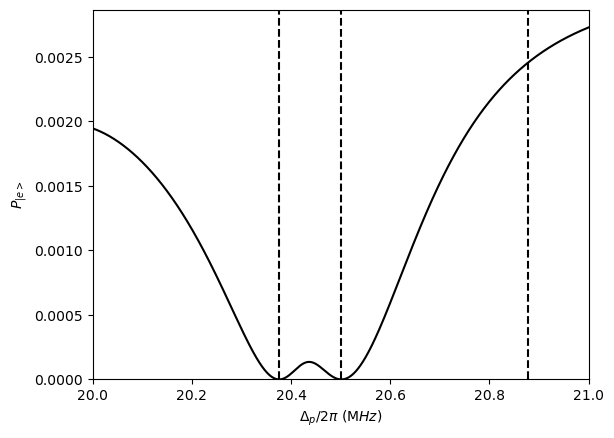

In [28]:
plt.figure()
#plt.plot(np.linspace(-10*GammaJgJe,20*GammaJgJe,200),pope1)
plt.plot(np.linspace(Dmin,Dmax,NN),pope,color='black')
#for i in range(len(Delta_ds)):
    #plt.axvline(Delta_ds[i], linestyle=(0, (1, 10)))
plt.ylabel('$P_{|e>}$')
plt.xlabel('$Δ_{p}/2π \ (ΜHz)$')
plt.ylim(0)
plt.axvline(Delta_ds[-1], linestyle='--',color='black')
plt.axvline(Delta_ds[-2], linestyle='--',color='black')
plt.axvline(Delta_ds[-3], linestyle='--',color='black')

#plt.axvline(10.787075035802768, linestyle='--')
#plt.axvline(65, linestyle='--' )
plt.xlim(20,21)
#plt.ylim(0,1e-9)

#plt.savefig("I1_abs_1_ds.png",bbox_inches = "tight")
plt.show()

In [29]:
omega = [23.5,10,23.5]
#Rabi frequencies Ω_F,F' #1/2π (MHz)

#turn on/off polarization
Omega_p= np.zeros((3,3)) # (ig-1, q + 1) transition from F[ig] state to F' with polarization q

Omega_p[0,0] = Omega_p[0,2] = omega[0]       #σ+ and σ- for F=F[1] to F'= F[0]
Omega_p[1,0] = Omega_p[1,2] = omega[1]      #σ+ and σ- for F=F[2] to F'=F[0]
Omega_p[2,0] = Omega_p[2,2] = omega[2]     #σ+ and σ- for F=F[3] to F'=F[0]

Delta = [0,10,Delta_ds[-2],20]

 #HI - laser-ion interaction      
HI=H_I(F,Omega_p) 
#H0 - ion
H0 = H_0(F,Delta)
#total Hamiltonian
H = H0 + HI
#make sure Hamiltonian is sparse
H = H.to("CSR").tidyup(atol=1e-8)
rho = steadystate(H,c_ops)

In [30]:
Q = basis(N,0)*basis(N,0).dag() + basis(N,1)*basis(N,1).dag() + basis(N,2)*basis(N,2).dag()
Q

Quantum object: dims=[[12], [12]], shape=(12, 12), type='oper', dtype=Dense, isherm=True
Qobj data =
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

In [31]:
P=qeye(N)-Q

In [32]:
(P*H*P).diag() #detunings degeneracy ds=1

array([ 0.        ,  0.        ,  0.        , 10.        , 20.43884635,
       20.50153869, 20.56423102, 19.1223073 , 19.56115365, 20.        ,
       20.43884635, 20.8776927 ])

In [33]:
Ps = Qobj(np.diag([0,0,0,0,1,0,0,0,0,0,1,0]))
# Ps = Qobj(np.diag([0,0,0,0,0,1,0,0,0,0,0,1]))

In [34]:
matrix_rank((Q*H*Ps).data_as('ndarray')) # rank(QHPs) <= ds-1 => 1=1 => dark state!

1

In [35]:
omega = [23.5,10,23.5]
#Rabi frequencies Ω_F,F' #1/2π (MHz)

#turn on/off polarization
Omega_p= np.zeros((3,3)) # (ig-1, q + 1) transition from F[ig] state to F' with polarization q

Omega_p[0,0] = Omega_p[0,2] = omega[0]       #σ+ and σ- for F=F[1] to F'= F[0]
Omega_p[1,0] = Omega_p[1,2] = omega[1]      #σ+ and σ- for F=F[2] to F'=F[0]
Omega_p[2,0] = Omega_p[2,2] = omega[2]     #σ+ and σ- for F=F[3] to F'=F[0]

Delta = [0,10,Delta_ds[-3],20]

 #HI - laser-ion interaction      
HI=H_I(F,Omega_p) 
#H0 - ion
H0 = H_0(F,Delta)
#total Hamiltonian
H = H0 + HI
#make sure Hamiltonian is sparse
H = H.to("CSR").tidyup(atol=1e-8)
rho1 = steadystate(H,c_ops)

In [36]:
(P*H*P).diag() #detunigs degeneracy ds=2

array([ 0.        ,  0.        ,  0.        , 10.        , 20.31346168,
       20.37615401, 20.43884635, 19.1223073 , 19.56115365, 20.        ,
       20.43884635, 20.8776927 ])

In [37]:
 Ps = Qobj(np.diag([0,0,0,0,0,0,1,0,0,0,1,0]))

In [38]:
matrix_rank((Q*H*Ps).data_as('ndarray')) # 1=1

1

In [39]:
omega = [23.5,10,23.5]
#Rabi frequencies Ω_F,F' #1/2π (MHz)

#turn on/off polarization
Omega_p= np.zeros((3,3)) # (ig-1, q + 1) transition from F[ig] state to F' with polarization q

Omega_p[0,0] = Omega_p[0,2] = omega[0]       #σ+ and σ- for F=F[1] to F'= F[0]
Omega_p[1,0] = Omega_p[1,2] = omega[1]      #σ+ and σ- for F=F[2] to F'=F[0]
Omega_p[2,0] = Omega_p[2,2] = omega[2]     #σ+ and σ- for F=F[3] to F'=F[0]

Delta = [0,10,Delta_ds[-1],20]

 #HI - laser-ion interaction      
HI=H_I(F,Omega_p) 
#H0 - ion
H0 = H_0(F,Delta)
#total Hamiltonian
H = H0 + HI
#make sure Hamiltonian is sparse
H = H.to("CSR").tidyup(atol=1e-8)
rho2 = steadystate(H,c_ops)

In [40]:
(P*H*P).diag() #detunigs degeneracy ds=2

array([ 0.        ,  0.        ,  0.        , 10.        , 20.81500037,
       20.8776927 , 20.94038504, 19.1223073 , 19.56115365, 20.        ,
       20.43884635, 20.8776927 ])

In [41]:
Ps = Qobj(np.diag([0,0,0,0,0,1,0,0,0,0,0,1]))

In [42]:
matrix_rank((Q*H*Ps).data_as('ndarray')) #rank(QHPs)>ds-1 => no dark state!

2

In [43]:
omega = [23.5*np.sqrt(2),10*np.sqrt(2),23.5*np.sqrt(2)]

#turn on/off polarization
Omega_p= np.zeros((3,3)) # (ig-1, q + 1) transition from F state to F' with polarization q

#polarization when laser direction k in an angle θ with quantization axis z k = sin(θ)x + cos(θ)z
#                                                                           e = cos(θ)x - sin(θ)z (cartesian)
#                                                                           e = -1/sqrt(2)cos(θ)ε+ + 1/sqrt(2)cos(θ)ε- -sin(θ)ε0 (pol basis)
#                                                                       
 
theta = 5*2*np.pi/360

Omega_p[0,0] = 1/np.sqrt(2)*np.cos(theta)*omega[0]
Omega_p[0,1] = -np.sin(theta)*omega[0] 
Omega_p[0,2] = -1/np.sqrt(2)*np.cos(theta)*omega[0]  

Omega_p[1,0] = 1/np.sqrt(2)*np.cos(theta)*omega[1]
Omega_p[1,1] = -np.sin(theta)*omega[1] 
Omega_p[1,2] = -1/np.sqrt(2)*np.cos(theta)*omega[1]  

Omega_p[2,0] = 1/np.sqrt(2)*np.cos(theta)*omega[2]
Omega_p[2,1] = -np.sin(theta)*omega[2] 
Omega_p[2,2] = -1/np.sqrt(2)*np.cos(theta)*omega[2] 

Delta = [0,10,20.5,20]

In [44]:
 #HI - laser-ion interaction      
HI=H_I(F,Omega_p) 
#H0 - ion
Delta = [0,10,20.5,20]
H0 = H_0(F,Delta)
#total Hamiltonian
H = H0 + HI
#make sure Hamiltonian is sparse
H = H.to("CSR").tidyup(atol=1e-8)
rho1 = steadystate(H,c_ops)

In [45]:
(P*H*P).diag()

array([ 0.        ,  0.        ,  0.        , 10.        , 20.43730766,
       20.5       , 20.56269234, 19.1223073 , 19.56115365, 20.        ,
       20.43884635, 20.8776927 ])

In [46]:
Ps = Qobj(np.diag([0,0,0,0,0,0,1,0,0,0,1,0]))

In [47]:
matrix_rank((Q*H*Ps).data_as('ndarray')) #=> pi pol destroys dark state

2

In [48]:
rho1[0][0]+rho1[1][1]+rho1[2][2]

(0.0016488188571840365+0j)

In [49]:
HI=0*basis(N,0)*basis(N,0).dag() #lowering rank(Q*H*Ps) (unphysical)
for mFe in range(-F[0],F[0] + 1):
    for ig in range(1,len(F)):
        for mFg in range(-F[ig],F[ig]+1):
            for q in range(-1,2):
                if mFe==-1 and F[ig]==1 and mFg==-1:
                    HI+=0*basis(N,0)*basis(N,0).dag()
                elif mFe==0 and F[ig]==1 and mFg==-1:
                    HI+=0*basis(N,0)*basis(N,0).dag()
                elif mFe==0 and F[ig]==2 and mFg==1:
                    HI+=0*basis(N,0)*basis(N,0).dag()
                elif mFe==1 and F[ig]==2 and mFg==1:
                    HI+=0*basis(N,0)*basis(N,0).dag()
                else:
                    HI += cg(F,ig,mFg,0,mFe,q)*Omega_p[ig-1,q+1]/2*base(F,0,mFe)*base(F,ig,mFg).dag()
                
HI=-1/np.sqrt(2*F[0]+1)*(HI + HI.dag()) 

In [50]:
#total Hamiltonian
H = H0 + HI
#make sure Hamiltonian is sparse
H = H.to("CSR").tidyup(atol=1e-8)
rho2 = steadystate(H,c_ops)

In [51]:
(P*H*P).diag()

array([ 0.        ,  0.        ,  0.        , 10.        , 20.43730766,
       20.5       , 20.56269234, 19.1223073 , 19.56115365, 20.        ,
       20.43884635, 20.8776927 ])

In [52]:
matrix_rank((Q*H*Ps).data_as('ndarray'))

1

In [53]:
np.arange(1,6,1)

array([1, 2, 3, 4, 5])

In [54]:
omega = [23.5*np.sqrt(2),10*np.sqrt(2),23.5*np.sqrt(2)]

#turn on/off polarization
Omega_p= np.zeros((3,3)) # (ig-1, q + 1) transition from F state to F' with polarization q

#polarization when laser direction k in an angle θ with quantization axis z k = sin(θ)x + cos(θ)z
#                                                                           e = cos(θ)x - sin(θ)z (cartesian)
#                                                                           e = -1/sqrt(2)cos(θ)ε+ + 1/sqrt(2)cos(θ)ε- -sin(θ)ε0 (pol basis)
#                                                                           e = y (unaffected by θ?)
pope_theta = []
for thet in range(0,6,1):
    theta = thet*2*np.pi/360

    Omega_p[0,0] = 1/np.sqrt(2)*np.cos(theta)*omega[0]
    Omega_p[0,1] = -np.sin(theta)*omega[0] 
    Omega_p[0,2] = -1/np.sqrt(2)*np.cos(theta)*omega[0]  

    Omega_p[1,0] = 1/np.sqrt(2)*np.cos(theta)*omega[1]
    Omega_p[1,1] = -np.sin(theta)*omega[1] 
    Omega_p[1,2] = -1/np.sqrt(2)*np.cos(theta)*omega[1]  

    Omega_p[2,0] = 1/np.sqrt(2)*np.cos(theta)*omega[2]
    Omega_p[2,1] = -np.sin(theta)*omega[2] 
    Omega_p[2,2] = -1/np.sqrt(2)*np.cos(theta)*omega[2] 

    Delta = [0,10,20.5,20]
    pope_= pop_e(F,N,Delta,Omega_p,c_ops,Dmin,Dmax,NN)
    pope_theta.append(pope_)

100%|██████████| 4000/4000 [00:05<00:00, 717.57it/s]


In [55]:
5*2*np.pi/360

0.08726646259971647

In [56]:
np.cos(5*2*np.pi/360)

0.9961946980917455

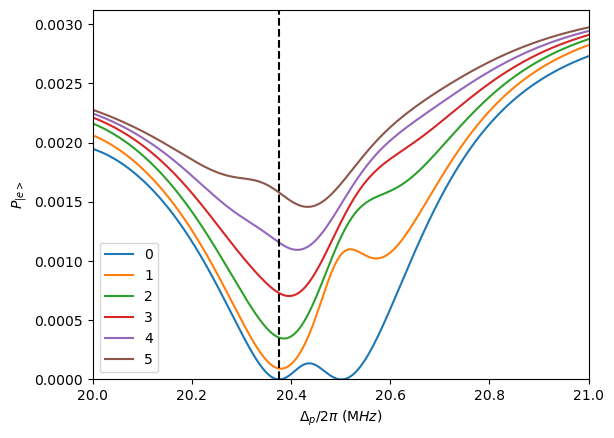

In [57]:
plt.figure()
#plt.plot(np.linspace(-10*GammaJgJe,20*GammaJgJe,200),pope1)
for i in range(len(pope_theta)):
    plt.plot(np.linspace(Dmin,Dmax,NN),pope_theta[i],label=range(0,6,1)[i])

#for i in range(len(Delta_ds)):
    #plt.axvline(Delta_ds[i], linestyle=(0, (1, 10)))
plt.ylabel('$P_{|e>}$')
plt.xlabel('$Δ_{p}/2π \ (ΜHz)$')
plt.ylim(0)
plt.legend()
#plt.axvline(Delta_ds[-3] + 1.4, linestyle='--',color='red')
plt.axvline(Delta_ds[-3], linestyle='--',color='black')
#plt.axvline(Delta_ds[-3] - 1.4, linestyle='--',color='blue')
#plt.axvline(10.787075035802768, linestyle='--')
#plt.axvline(65, linestyle='--' )
plt.xlim(20,21)

#plt.savefig("I1_abs_1_ds.png",bbox_inches = "tight")
plt.show()

In [58]:
GammaJgJe

2.44745

In [59]:
2*np.pi*GammaJgJe*pope_theta[1][int((Delta_ds[-3]-Dmin)/step)]

0.0014095905178214264

In [60]:
colors = cm.Purples(np.linspace(0,1,8))

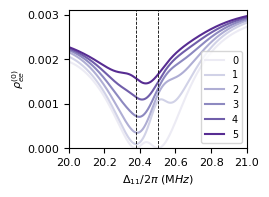

In [61]:
plt.rcParams.update({'font.size': 8})
plt.figure(figsize=(2.3,1.8))
#plt.plot(np.linspace(-10*GammaJgJe,20*GammaJgJe,200),pope1)
for i in range(len(pope_theta)):
    plt.plot(np.linspace(Dmin,Dmax,NN),pope_theta[i],label=range(0,6,1)[i],color=colors[i+1])

#for i in range(len(Delta_ds)):
    #plt.axvline(Delta_ds[i], linestyle=(0, (1, 10)))
plt.ylabel(r'$\rho_{ee}^{(0)}$',labelpad=0)
plt.xlabel('$Δ_{11}/2π \ (ΜHz)$')
plt.ylim(0)
plt.legend(fontsize= 7)
#plt.axvline(Delta_ds[-3] + 1.4, linestyle='--',color='red')
plt.axvline(Delta_ds[-3], linestyle='--',color='black',linewidth=0.6)
plt.axvline(Delta_ds[-2], linestyle='--',color='black',linewidth=0.6)
#plt.axvline(Delta_ds[-3] - 1.4, linestyle='--',color='blue')
#plt.axvline(10.787075035802768, linestyle='--')
#plt.axvline(65, linestyle='--' )
plt.xlim(20,21)

plt.savefig("I1_abs_pol.pdf",bbox_inches = "tight")
plt.show()

## Fictitious lasers

In [62]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [63]:
def H1_(F,eta,Omega_p):
    H1=0*basis(N,0)*basis(N,0).dag()
    for mFe in range(-F[0],F[0] + 1):
        for ig in range(1,len(F)):
            for mFg in range(-F[ig],F[ig]+1):
                for q in range(-1,2):
                    H1 += eta[ig-1]*cg(F,ig,mFg,0,mFe,q)*Omega_p[ig-1,q+1]/2*base(F,0,mFe)*base(F,ig,mFg).dag()
                
    return -1/np.sqrt(2*F[0]+1)*H1

In [64]:
def steck(F,N,Delta,Omega_p,eta,c,Dmin, Dmax,nn):
    H0_ = H_0(F,Delta)
    HI_ = H_I(F,Omega_p) 
    

    H0 = H0_ + HI_ 
    #H0 = H0.to("CSR").tidyup(atol=1e-8)

    rho0 = steadystate(H0,c)

    L0 = 0*spre(c[0])*spost(c[0].dag())
    for i in range(len(c)):
        L0 += spre(c[i])*spost(c[i].dag()) - 0.5*(spre(c[i].dag()*c[i]) + spost(c[i].dag()*c[i]))
    #L0 = sum(c)

    L0 += -1j*(spre(H0) - spost(H0))
    
    #L0 = np.array(L0)
    L0 = L0.data_as('ndarray')

    H_1 = H1_(F,eta,Omega_p)
    L_1 = -1j*(spre(H_1) - spost(H_1))

    #L_1 = np.array(L_1)
    L_1 = L_1.data_as('ndarray')

    H1 = H_1.dag()
    L1 = -1j*(spre(H1) - spost(H1))

    #L1 = np.array(L1)
    L1 = L1.data_as('ndarray')
   
    #popes = np.zeros(nn,dtype='complex64')
    #coh = np.zeros(nn,dtype='complex64')
    abs = np.zeros(nn,dtype='complex64')
    
    k=0

    for Deltap in tqdm(np.linspace(Dmin,Dmax,nn)):


        S3 = -np.matmul(inv(L0-3j*Deltap*np.eye(N**2)),L1)
        #S2 = -np.matmul(inv(L0-2j*Deltap*np.eye(N**2)),L1)
        S2 = -np.matmul(inv(L0-2j*Deltap*np.eye(N**2)+ np.matmul(L_1,S3)),L1)
        S1 = -np.matmul(inv(L0-1j*Deltap*np.eye(N**2) + np.matmul(L_1,S2)),L1)
        #S1 = -np.matmul(inv(L0-1j*Deltap*np.eye(N**2)),L1) 

        T_3 = -np.matmul(inv(L0+3j*Deltap*np.eye(N**2)),L_1)
        #T_2 = -np.matmul(inv(L0+2j*Deltap*np.eye(N**2)),L_1)
        T_2 = -np.matmul(inv(L0+2j*Deltap*np.eye(N**2)+ np.matmul(L1,T_3)),L_1)
        T_1 = -np.matmul(inv(L0+1j*Deltap*np.eye(N**2)+ np.matmul(L1,T_2)),L_1)
        #T_1 = -np.matmul(inv(L0+1j*Deltap*np.eye(N**2)),L_1)
    
        L = np.matmul(L_1,S1) + L0 +np.matmul(L1,T_1)
    
        eigenvalues, eigenvectors = eigs(L,k=1,sigma = 0+0j)

        rhoss = eigenvectors[:,0]

        rhos = np.zeros((N,N),dtype='complex64')
        for i in range(N):
            for j in range(N):
                rhos[j,i] = rhoss[j+i*N]

        rho = Qobj(rhos)
        if rho.tr() != 0:
            rho = rho/rho.tr()

        rho_ = operator_to_vector(rho)
        #rho_ = np.array(rho_)
        rho_ = rho_.data_as('ndarray')

        rho1 = np.matmul(S1,rho_)
        #rho2 = np.matmul(S2,rho_)
        #rho3 = np.matmul(S3,rho_)

        rho_1 = np.matmul(T_1,rho_)
        #rho_2 = np.matmul(T_2,rho_)
        #rho_3 = np.matmul(T_3,rho_)

        rhos1 = np.zeros((N,N),dtype='complex64')
        #rhos2 = np.zeros((N,N),dtype='complex64')
        #rhos3 = np.zeros((N,N),dtype='complex64')
        rhos_1 = np.zeros((N,N),dtype='complex64')
        #rhos_2 = np.zeros((N,N),dtype='complex64')
        #rhos_3 = np.zeros((N,N),dtype='complex64')
        for i in range(N):
            for j in range(N):
                rhos1[j,i] = rho1[j+i*N]
                #rhos2[j,i] = rho2[j+i*N]
                #rhos3[j,i] = rho3[j+i*N]
                rhos_1[j,i] = rho_1[j+i*N]
                #rhos_2[j,i] = rho_2[j+i*N]
                #rhos_3[j,i] = rho_3[j+i*N]
            
        Rho1 = Qobj(rhos1)
        #Rho2 = Qobj(rhos2)
        #Rho3 = Qobj(rhos3)
        Rho_1 = Qobj(rhos_1)
        #Rho_2 = Qobj(rhos_2)
        #Rho_3 = Qobj(rhos_3)

        #ree = 0+0j
        #rcoh = 0+0j
        rabs= 0+0j
        for ig in range(1,len(F)):
            for mfg in range(-F[ig],F[ig] + 1):
                for mfe in range(-F[0],F[0]+1):
                    for q in range(-1,2):
                        #ree+=2*np.pi*1/(2*F[0] + 1)*cg(F,ig,mfg,0,mfe,q)**2*GammaFgFe(F,ig,Je,Jg,I,GammaJgJe)*(
                            #expect(base(F,0,mfe)*base(F,0,mfe).dag(),rho))

                        #rcoh+=-1j*2*np.pi*cg(F,ig,mfg,0,mfe,q)*Omega_p[ig-1,q+1]/2*1/np.sqrt(2*F[0]+1)*(
                            #expect(base(F,ig,mfg)*base(F,0,mfe).dag(),rho) -(
                                #expect(base(F,0,mfe)*base(F,ig,mfg).dag(),rho)))

                        rabs+=-1j*2*np.pi*eta[ig-1]*cg(F,ig,mfg,0,mfe,q)*Omega_p[ig-1,q+1]/2*1/np.sqrt(2*F[0]+1)*(
                            expect(base(F,ig,mfg)*base(F,0,mfe).dag(),Rho_1)-expect(base(F,0,mfe)*base(F,ig,mfg).dag(),Rho1))

        #popes[k] = ree
        #coh[k] = rcoh
        abs[k] = rabs
        k+=1
        

    return abs

In [65]:
#system parameters
c = 299792458
λ = 646e-9
f = c/λ 
f_1 = 11.2e9
f_2 = 10.5e9

#176Lu+
amu = 1.66053886e-27
hbar = 1.054571817e-34
M = 176*amu

omega0  = 1.4

eta = []

eta2 = 2*np.pi*f/c*np.sqrt(hbar/(2*M*2*np.pi*omega0*10**(6)))
eta.append(eta2)

eta3 = 2*np.pi*(f-f_1)/c*np.sqrt(hbar/(2*M*2*np.pi*omega0*10**(6)))
eta.append(eta3)

eta4 = -2*np.pi*(f-f_2)/c*np.sqrt(hbar/(2*M*2*np.pi*omega0*10**(6)))
eta.append(eta4)

#eta = [0.01,0.01,-0.01]
#eta = [1e-4,1e-4,-1e-4]
#eta = [1e-8,1e-8,-1e-8]
#eta = [0.1,0.1,-0.1]
eta

[0.044048956567528934, 0.0440478934887154, -0.04404795993114125]

In [66]:
omega = [23.5*np.sqrt(2),10*np.sqrt(2),23.5*np.sqrt(2)]

#turn on/off polarization
Omega_p= np.zeros((3,3)) # (ig-1, q + 1) transition from F state to F' with polarization q

#polarization when laser direction k in an angle θ with quantization axis z k = sin(θ)x + cos(θ)z
#                                                                           e = cos(θ)x - sin(θ)z (cartesian)
#               
#                                                             e = -1/sqrt(2)cos(θ)ε+ + 1/sqrt(2)cos(θ)ε- -sin(θ)ε0 (pol basis)

abs_theta = []
for thet in range(0,6,1):
 
    theta = thet*2*np.pi/360

    Omega_p[0,0] = 1/np.sqrt(2)*np.cos(theta)*omega[0]
    Omega_p[0,1] = -np.sin(theta)*omega[0] 
    Omega_p[0,2] = -1/np.sqrt(2)*np.cos(theta)*omega[0]  

    Omega_p[1,0] = 1/np.sqrt(2)*np.cos(theta)*omega[1]
    Omega_p[1,1] = -np.sin(theta)*omega[1] 
    Omega_p[1,2] = -1/np.sqrt(2)*np.cos(theta)*omega[1]  

    Omega_p[2,0] = 1/np.sqrt(2)*np.cos(theta)*omega[2]
    Omega_p[2,1] = -np.sin(theta)*omega[2] 
    Omega_p[2,2] = -1/np.sqrt(2)*np.cos(theta)*omega[2] 

    Delta = [0,10,20.38,20]

    Dmin_ = -2.5
    Dmax_ = 2.5
    nn_ = 2000
    step = (Dmax_-Dmin_)/nn_
    

    params = dict(F=F,N=N,Delta=Delta,Omega_p=Omega_p,eta=eta,c=c_ops,Dmin=Dmin_, Dmax=Dmax_,nn=nn_)
    abs = steck(**params)
    abs_theta.append(abs)

  0%|          | 0/2000 [00:00<?, ?it/s]C:\Users\kfouka\AppData\Local\Temp\ipykernel_28348\805549890.py:89: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rhos1[j,i] = rho1[j+i*N]
C:\Users\kfouka\AppData\Local\Temp\ipykernel_28348\805549890.py:92: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rhos_1[j,i] = rho_1[j+i*N]
100%|██████████| 2000/2000 [01:11<00:00, 28.09it/s]


c:\Users\kfouka\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\kfouka\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


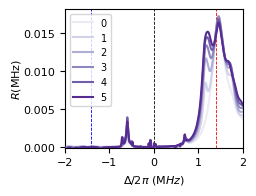

In [67]:
plt.rcParams.update({'font.size': 8})
plt.figure(figsize=(2.3,1.8))
#plt.plot(np.linspace(-10*GammaJgJe,20*GammaJgJe,200),pope1)
for i in range(len(pope_theta)):
    plt.plot(np.linspace(Dmin_,Dmax_,nn_),abs_theta[i],label=range(0,6,1)[i],color=colors[i+1],zorder=i)

#for i in range(len(Delta_ds)):
    #plt.axvline(Delta_ds[i], linestyle=(0, (1, 10)))
plt.ylabel('$R$(MHz)',labelpad=0)
plt.xlabel('$Δ/2π \ (ΜHz)$')
plt.ylim(-1e-4)
plt.legend(fontsize= 7)
plt.axvline(0 + 1.4, linestyle='--',color='red',linewidth=0.6,)
plt.axvline(0, linestyle='--',color='black',linewidth=0.6)
plt.axvline(0 - 1.4, linestyle='--',color='blue',linewidth=0.6)
#plt.axvline(10.787075035802768, linestyle='--')
#plt.axvline(65, linestyle='--' )
plt.xlim(-2,2)

plt.savefig("I1_fic_pol.pdf",bbox_inches = "tight")
plt.show()

## Cooling

In [68]:
from scipy.optimize import minimize_scalar

In [69]:
def func(x,Nmax,nbar):
    
    Z = (1-np.exp(-(Nmax+1)*x))/(1-np.exp(-x))
    n = np.exp(-Nmax*x)*(np.exp((Nmax + 1)*x) -(Nmax+1)*np.exp(x) + Nmax)/(np.exp(x) -1)**2
    
    
    return np.abs(nbar - n/Z)

In [70]:
Nmax=14
nbar=3
res = minimize_scalar(func,args=(Nmax,nbar),bounds=(0, 1), method='bounded')

In [71]:
x = res.x

In [72]:
hbar = 1.054571817e-34
kB = 1.380649e-23
omega = 2*np.pi*1.4*10e6
#x = 0.184132
Z = (1-np.exp(-(Nmax+1)*x))/(1-np.exp(-x))

T = hbar*omega/(kB*x)
T

0.002527075613606284

In [73]:
P = []
for i in range(Nmax+1): #Nmotion=15 but for <n> =3 keep up to i=10
    P.append(np.exp(-i*x)/Z)

In [74]:
Pn = []
for i in range(Nmax+1):
    Pn.append(np.exp(-i*x)/Z*i)

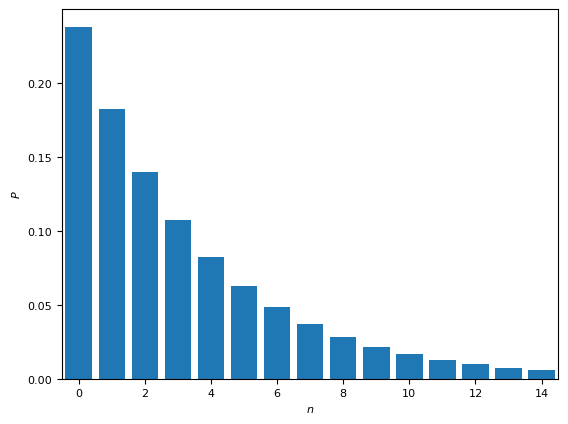

In [75]:
plt.figure()
plt.bar(np.arange(0,Nmax+1),P)
plt.ylabel('$P$')
plt.xlabel('$n$')
plt.xlim(-0.5,Nmax+0.5)
plt.show()

In [ ]:
t = []
n = []
n_div = []
for i in range(Nmax+1):
    t.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_0_ntraj_500_improved_step_LD.txt")[:, 0])
    n.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_0_ntraj_500_improved_step_LD.txt")[:, 1])
    n_div.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_0_ntraj_500_stds_improved_step_LD.txt")[:, 0])          

In [77]:
nMC = np.zeros(len(t[0]))
for i in range(Nmax+1):
    nMC +=np.array(n[i])*P[i]

In [78]:
nMC_dev = np.zeros(len(t[0]))
for i in range(Nmax+1):
    nMC_dev += np.array(n_div[i])*P[i]
nMC_dev = nMC_dev/np.sqrt(500-1)

In [79]:
nMC_dev

array([1.34836170e-08, 1.92831431e-03, 3.69608109e-03, ...,
       2.59811627e-03, 2.53909715e-03, 2.50237758e-03])

In [ ]:
t1 = []
n1 = []
n_div1 = []
for i in range(Nmax+1):
    t1.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_1_ntraj_500_improved_step_LD.txt")[:, 0])
    n1.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_1_ntraj_500_improved_step_LD.txt")[:, 1])
    n_div1.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_0_ntraj_500_stds_improved_step_LD.txt")[:, 0])

In [81]:
nMC1 = np.zeros(len(t[0]))
for i in range(Nmax+1):
    nMC1 +=np.array(n1[i])*P[i]

In [82]:
nMC_dev1 = np.zeros(len(t[0]))
for i in range(Nmax+1):
    nMC_dev1 += np.array(n_div1[i])*P[i]
nMC_dev1 = nMC_dev1/np.sqrt(500-1)

In [83]:
nMC_dev1

array([1.34836170e-08, 1.92831431e-03, 3.69608109e-03, ...,
       2.59811627e-03, 2.53909715e-03, 2.50237758e-03])

In [ ]:
t2 = []
n2 = []
n_div2 = []
for i in range(Nmax+1):
    t2.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_2_ntraj_500_improved_step_LD.txt")[:, 0])
    n2.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_2_ntraj_500_improved_step_LD.txt")[:, 1])
    n_div2.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_2_ntraj_500_stds_improved_step_LD.txt")[:, 0])         

In [85]:
nMC2 = np.zeros(len(t[0]))
for i in range(Nmax+1):
    nMC2 +=np.array(n2[i])*P[i]

In [86]:
nMC_dev2 = np.zeros(len(t[0]))
for i in range(Nmax+1):
    nMC_dev2 += np.array(n_div2[i])*P[i]
nMC_dev2 = nMC_dev2/np.sqrt(500-1)

In [ ]:
t3 = []
n3 = []
n_div3 = []
for i in range(Nmax+1):
    t3.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_3_ntraj_500_improved_step_LD.txt")[:, 0])
    n3.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_3_ntraj_500_improved_step_LD.txt")[:, 1])
    n_div3.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_3_ntraj_500_stds_improved_step_LD.txt")[:, 0]) 

In [88]:
nMC3 = np.zeros(len(t[0]))
for i in range(Nmax+1):
    nMC3 +=np.array(n3[i])*P[i]

In [89]:
nMC_dev3 = np.zeros(len(t[0]))
for i in range(Nmax+1):
    nMC_dev3 += np.array(n_div3[i])*P[i]
nMC_dev3 = nMC_dev3/np.sqrt(500-1)

In [ ]:
t4 = []
n4 = []
n_div4 = []
for i in range(Nmax+1):
    t4.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_4_ntraj_500_improved_step_LD.txt")[:, 0])
    n4.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_4_ntraj_500_improved_step_LD.txt")[:, 1])
    n_div4.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_4_ntraj_500_stds_improved_step_LD.txt")[:, 0]) 

In [91]:
nMC4 = np.zeros(len(t[0]))
for i in range(Nmax+1):
    nMC4 +=np.array(n4[i])*P[i]

In [92]:
nMC_dev4 = np.zeros(len(t[0]))
for i in range(Nmax+1):
    nMC_dev4 += np.array(n_div4[i])*P[i]
nMC_dev4 = nMC_dev4/np.sqrt(500-1)

In [ ]:
t5 = []
n5 = []
n_div5 = []
for i in range(Nmax+1):
    t5.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_5_ntraj_500_improved_step_LD.txt")[:, 0])
    n5.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_5_ntraj_500_improved_step_LD.txt")[:, 1])
    n_div5.append(np.loadtxt(""+str(path_name)+"data_B5.0_D10_10_D12_20_O10_O11_33.23401871576774_O11_14.142135623730951_"+str(i)+"_Gamma_2.44745_theta_5_ntraj_500_stds_improved_step_LD.txt")[:, 0]) 

In [94]:
nMC5 = np.zeros(len(t[0]))
for i in range(Nmax+1):
    nMC5 +=np.array(n5[i])*P[i]

In [95]:
nMC_dev5 = np.zeros(len(t[0]))
for i in range(Nmax+1):
    nMC_dev5 += np.array(n_div5[i])*P[i]
nMC_dev5 = nMC_dev5/np.sqrt(500-1)

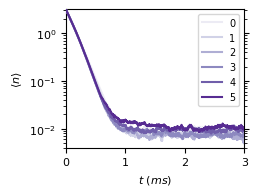

In [96]:
plt.rcParams.update({'font.size': 8})
plt.figure(figsize=(2.3,1.8))
plt.plot(t[0]*1e-3,nMC,color=colors[1],label=0,zorder=1)
plt.plot(t1[0]*1e-3,nMC1,color=colors[2],label=1,zorder=2)
plt.plot(t2[0]*1e-3,nMC2,color=colors[3],label=2,zorder=3)
plt.plot(t3[0]*1e-3,nMC3,color=colors[4],label=3,zorder=4)
plt.plot(t4[0]*1e-3,nMC4,color=colors[5],label=4,zorder=5)
plt.plot(t5[0]*1e-3,nMC5,color=colors[6],label=5,zorder=5)

plt.ylabel(r'$ \langle n \rangle $')
plt.xlabel(r'$t \ (ms)$')
plt.ylim(4e-3,3.2)
plt.xlim(0,3)
plt.yscale('log')
#plt.xlim(0,100)
#ax4.legend(prop={'size': 10})
plt.tick_params(axis='y', which='both', left=True, right=True, 
               labelleft=True, labelright=False)
plt.legend(fontsize=7)
plt.savefig("I1_cool_pol.pdf",bbox_inches = "tight")
plt.show()

C:\Users\kfouka\AppData\Local\Temp\ipykernel_28348\1739755577.py:70: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


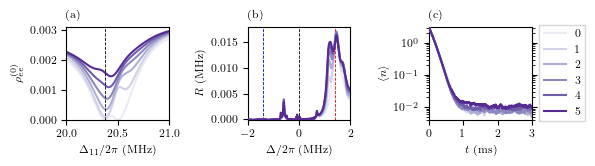

In [98]:
# Create a mosaic where each plot is two entries wide.  Dots represent spaces.
plt.rcParams.update({'font.size': 8})
from matplotlib import rc
 
rc('text', usetex=True)
rc("mathtext", fontset = "cm")
rc("font", family="DejaVu Serif", serif="Times New Roman")
mosaic = """ABC"""

fig, ax_dict = plt.subplot_mosaic(mosaic, figsize=(6,1.7),constrained_layout=True)


ax_dict['A'].set_title(r'(a)',loc='left',fontdict={'fontsize': 8})
for i in range(len(pope_theta)):
    ax_dict['A'].plot(np.linspace(Dmin,Dmax,NN),pope_theta[i],label=range(0,6,1)[i],color=colors[i+1])

#for i in range(len(Delta_ds)):
    #plt.axvline(Delta_ds[i], linestyle=(0, (1, 10)))
ax_dict['A'].set_ylabel('$\\rho_{ee}^{(0)}$')
ax_dict['A'].set_xlabel('$\Delta_{11}/2\pi$ (MHz)')
ax_dict['A'].set_ylim(0)
#ax_dict['A'].legend(fontsize= 7)
#plt.axvline(Delta_ds[-3] + 1.4, linestyle='--',color='red')
ax_dict['A'].axvline(Delta_ds[-3], linestyle='--',color='black',linewidth=0.6)
#plt.axvline(Delta_ds[-3] - 1.4, linestyle='--',color='blue')
#plt.axvline(10.787075035802768, linestyle='--')
#plt.axvline(65, linestyle='--' )
ax_dict['A'].set_xlim(20,21)


ax_dict['B'].set_title(r'(b)',loc='left',fontdict={'fontsize': 8})
for i in range(len(pope_theta)):
    ax_dict['B'].plot(np.linspace(Dmin_,Dmax_,nn_),abs_theta[i],label=range(0,6,1)[i],color=colors[i+1],zorder=i)

#for i in range(len(Delta_ds)):
    #plt.axvline(Delta_ds[i], linestyle=(0, (1, 10)))
ax_dict['B'].set_ylabel('$R$ (MHz)')
ax_dict['B'].set_xlabel('$\Delta/2\pi$ (MHz)')
ax_dict['B'].set_ylim(-1e-4)
ax_dict['B'].axvline(0 + 1.4, linestyle='--',color='red',linewidth=0.6,)
ax_dict['B'].axvline(0, linestyle='--',color='black',linewidth=0.6)
ax_dict['B'].axvline(0 - 1.4, linestyle='--',color='blue',linewidth=0.6)
#plt.axvline(10.787075035802768, linestyle='--')
#plt.axvline(65, linestyle='--' )
ax_dict['B'].set_xlim(-2,2)
#ax3.legend(loc='center left',prop={'size': 8},bbox_to_anchor=(1, 0.5))

ax_dict['C'].set_title(r'(c)',loc='left',fontdict={'fontsize': 8})
ax_dict['C'].plot(t[0]*1e-3,nMC,color=colors[1],label=0,zorder=1)
ax_dict['C'].plot(t1[0]*1e-3,nMC1,color=colors[2],label=1,zorder=2)
ax_dict['C'].plot(t2[0]*1e-3,nMC2,color=colors[3],label=2,zorder=3)
ax_dict['C'].plot(t3[0]*1e-3,nMC3,color=colors[4],label=3,zorder=4)
ax_dict['C'].plot(t4[0]*1e-3,nMC4,color=colors[5],label=4,zorder=5)
ax_dict['C'].plot(t5[0]*1e-3,nMC5,color=colors[6],label=5,zorder=5)

ax_dict['C'].set_ylabel('$ \\langle n \\rangle $')
ax_dict['C'].set_xlabel('$t$ (ms)')
ax_dict['C'].set_ylim(4e-3,3.2)
ax_dict['C'].set_xlim(0,3)
ax_dict['C'].set_yscale('log')
ax_dict['C'].legend(loc='center left',bbox_to_anchor=(1.02, 0.5),fancybox=False)
#plt.xlim(0,100)
#ax4.legend(prop={'size': 10})
ax_dict['C'].tick_params(axis='y', which='both', left=True, right=True, 
               labelleft=True, labelright=False)




plt.tight_layout()

plt.savefig("I1_all_pol_ds3.pdf",bbox_inches = "tight")
plt.show()